# Explanation sheets — counterfactual code

This notebook reproduces the counterfactual figures and explanation cards (counterfactual plus stability regions) in the paper. The repeated logic (decision maps,
leaf constraints, region sampling) lives in `counterfactual_helpers.py`, so each
figure below is only a few lines.

**Requirements:** `counterfactual_helpers.py` must sit next to this notebook.

Both data sets are downloaded on first use and cached in `data/`, so the notebook
runs anywhere with a network connection:

* **ACSIncome** (California, 2018) through `folktables` — a ~250 MB PUMS file,
  so the first run of Section 2 takes a few minutes.
* **South German Credit** ([UCI id 522](https://archive.ics.uci.edu/dataset/522/south+german+credit)) — a few kB.

Run the cells top to bottom.

## 1. Setup

In [ ]:
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scienceplots            # noqa: F401  (registers the "science" style)

import dice_ml
from folktables import ACSIncome, ACSDataSource
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from counterfactual_helpers import (
    load_south_german_credit, SOUTH_GERMAN_CREDIT_ORDINAL_RANGES,
    decision_grid, plot_decision_map, INDIVIDUAL_STYLE, COUNTERFACTUAL_STYLE,
    get_leaf_constraints, domain_bounds, print_region,
    verify_positive_region, verify_negative_region,
)

plt.style.use(["science", "no-latex"])
plt.rcParams["pdf.fonttype"] = 42          # avoid type-3 fonts in the figures
plt.rcParams["ps.fonttype"] = 42
plt.rcParams.update({"font.size": 32,
                     "xtick.labelsize": 24,
                     "ytick.labelsize": 24})

# Cosmetic only: sklearn warns whenever a model fitted on arrays is called with
# a DataFrame or vice versa, and pandas warns about how DiCE builds its search
# population. Neither affects the results, and both drown out the output.
warnings.filterwarnings("ignore", message="X has feature names")
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

SAVE_FIGURES = False       # set to True to write the PDFs used in the paper

: 

## 2. ACSIncome data (California, 2018)

In [ ]:
STATE, YEAR = "CA", 2018

data_source = ACSDataSource(survey_year=YEAR, survey="person", horizon="1-Year")
acs_data = data_source.get_data(states=[STATE], download=True)

X, y, _ = ACSIncome.df_to_numpy(acs_data)
feature_names = ACSIncome.features
feature_to_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# DataFrame views: the full data set defines the DiCE search space, the test
# frame supplies the median profile used as the individual in Figure 1
df = pd.DataFrame(X, columns=feature_names)
df["income"] = y
df_test = pd.DataFrame(X_test, columns=feature_names)

## 3. Train models

In [ ]:
def train_and_report(model, name, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    print(f"{name:<14} train acc: {accuracy_score(y_train, model.predict(X_train)):.3f}"
          f"   test acc: {accuracy_score(y_test, model.predict(X_test)):.3f}")
    return model


decision_tree = train_and_report(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    "Decision Tree", X_train, y_train, X_test, y_test)
rf = train_and_report(
    RandomForestClassifier(n_estimators=20, max_depth=None, random_state=42, n_jobs=-1),
    "Random Forest", X_train, y_train, X_test, y_test)

Decision Tree  train acc: 0.818   test acc: 0.805


Random Forest  train acc: 0.994   test acc: 0.806


## 4. Figure 1 — a counterfactual and the decision regions behind it

The individual is the median test profile, edited to an education level of 18
(some college, less than one year) and 20 working hours per week; both models
classify it as low income. DiCE is asked for counterfactuals that only change the hours worked.
Panel (a) shows the individual and its counterfactual on their own, panels (b)
and (c) add the decision regions of the two models over the same two features.

In [ ]:
# The individual to explain
person = df_test.median().to_dict()
person["SCHL"] = 18.0      # education: some college, less than one year
person["WKHP"] = 20        # hours worked per week

x_person = np.array([[person[f] for f in feature_names]])
print("Decision tree prediction:", decision_tree.predict(x_person)[0])
print("Random forest prediction:", rf.predict(x_person)[0])

Decision tree prediction: False
Random forest prediction: False


In [ ]:
# DiCE wrappers; AGEP and WKHP are the continuous features, the rest categorical
dice_data = dice_ml.Data(dataframe=df,
                         continuous_features=["AGEP", "WKHP"],
                         outcome_name="income")
dice_tree = dice_ml.Model(model=decision_tree, backend="sklearn")
dice_rf = dice_ml.Model(model=rf, backend="sklearn")

query_instance = pd.DataFrame([person])

In [ ]:
# Ten counterfactuals of the decision tree, varying the hours worked only
dice_tree_exp = dice_ml.Dice(dice_data, dice_tree, method="genetic")

random.seed(2)
np.random.seed(2)

cf_tree = dice_tree_exp.generate_counterfactuals(
    query_instance,
    total_CFs=10,
    desired_class="opposite",
    features_to_vary=["WKHP"],
    stopping_threshold=0.55,
)
cf_tree_df = cf_tree.cf_examples_list[0].final_cfs_df
print(cf_tree_df)


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:05<00:00,  5.18s/it]


100%|██████████| 1/1 [00:05<00:00,  5.18s/it]

   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P  income
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    40  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    41  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    42  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    43  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    44  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    47  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    48  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    49  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    50  1.0    1.0    True
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    51  1.0    1.0    True


In [ ]:
# Decision regions over hours worked x education, every other feature held at
# its median in the test set
GRID = dict(base_point=np.median(X_test, axis=0),
            x_idx=feature_to_idx["WKHP"],
            y_idx=feature_to_idx["SCHL"],
            x_range=(10, 60),
            y_range=(10, X[:, feature_to_idx["SCHL"]].max()))

xx, yy, Z_tree = decision_grid(decision_tree, **GRID)
_, _, Z_rf = decision_grid(rf, **GRID)

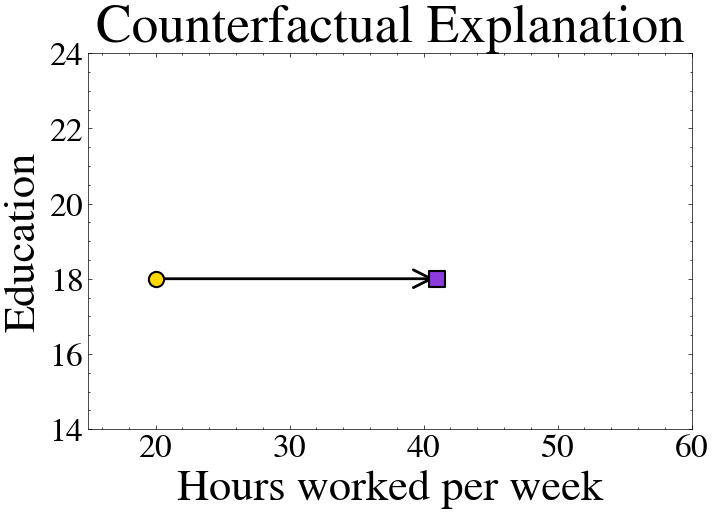

In [ ]:
# Figure 1a: the counterfactual on its own
individual = (person["WKHP"], person["SCHL"])
counterfactual_tree = (cf_tree_df["WKHP"].values[1], cf_tree_df["SCHL"].values[1])

fig, _ = plot_decision_map(xx, yy, Z_tree, individual, counterfactual_tree,
                           title="Counterfactual Explanation",
                           xlabel="Hours worked per week",
                           alpha=0, marker_size=120, arrow=True)
if SAVE_FIGURES:
    fig.savefig("counterfactual_plain.pdf", dpi=300, bbox_inches="tight")
plt.show()

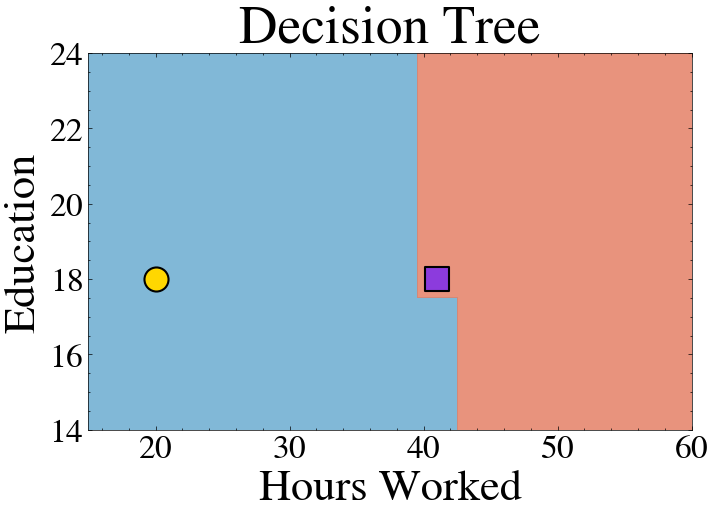

In [ ]:
# Figure 1b: the same pair on the decision tree's decision regions
fig, _ = plot_decision_map(xx, yy, Z_tree, individual, counterfactual_tree,
                           title="Decision Tree")
if SAVE_FIGURES:
    fig.savefig("decision_tree.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# One counterfactual of the random forest; the hours are restricted to [40, 42]
# so that the action stays comparable to the tree's
dice_rf_exp = dice_ml.Dice(dice_data, dice_rf, method="random")

random.seed(2)
np.random.seed(2)

cf_rf = dice_rf_exp.generate_counterfactuals(
    query_instance,
    total_CFs=1,
    desired_class="opposite",
    features_to_vary=["WKHP"],
    permitted_range={"WKHP": [40, 42]},
    stopping_threshold=0.55,
    posthoc_sparsity_param=0,
)
cf_rf_df = cf_rf.cf_examples_list[0].final_cfs_df
print(cf_rf_df)


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 11.01it/s]

   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P  income
0  42.0  1.0  18.0  1.0  4110.0   9.0   1.0    41  1.0    1.0    True


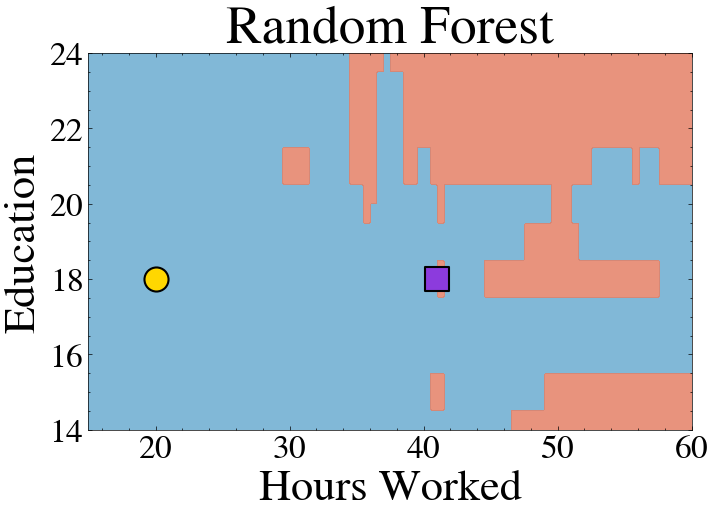

In [ ]:
# Figure 1c: the same individual on the random forest's decision regions
counterfactual_rf = (cf_rf_df["WKHP"].values[0], cf_rf_df["SCHL"].values[0])

fig, _ = plot_decision_map(xx, yy, Z_rf, individual, counterfactual_rf,
                           title="Random Forest")
if SAVE_FIGURES:
    fig.savefig("random_forest.pdf", dpi=300, bbox_inches="tight")
plt.show()

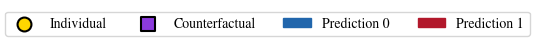

In [ ]:
# Legend shared by Figures 1a-1c (blue and red are the ends of the RdBu_r map)
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.axis("off")

handles = [
    ax.scatter([], [], s=100, label="Individual", **INDIVIDUAL_STYLE),
    ax.scatter([], [], s=100, label="Counterfactual", **COUNTERFACTUAL_STYLE),
    mpatches.Patch(color="#2166AC", label="Prediction 0"),
    mpatches.Patch(color="#B2182B", label="Prediction 1"),
]
ax.legend(handles=handles, loc="center", ncol=4, fontsize=10, frameon=True)

if SAVE_FIGURES:
    fig.savefig("legend_only.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 5. Explanation card for ACSIncome — stability regions

For a negatively classified test point we generate a counterfactual and then read
the two regions the explanation card reports, both from the leaves of the tree:

* the **Stabiliry region around the counterfactual**, in which the prediction
  stays positive, and
* the **Stability region around the input**, in which the prediction is still
  negative *and* the same action still flips it.

Both are verified by sampling.

In [ ]:
# The individual to explain and its counterfactual
person_np = X_test[13]
person_df = pd.DataFrame([person_np], columns=feature_names)
print("Model prediction:", decision_tree.predict(person_np.reshape(1, -1))[0])

dice_card_exp = dice_ml.Dice(dice_data, dice_tree, method="genetic")

random.seed(2)
np.random.seed(2)

cf_card = dice_card_exp.generate_counterfactuals(
    person_df,
    total_CFs=30,
    desired_class="opposite",
    features_to_vary=["WKHP", "SCHL"],
    stopping_threshold=0.6,
)
cf_card_df = cf_card.cf_examples_list[0].final_cfs_df

Model prediction: False



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:09<00:00,  9.08s/it]


100%|██████████| 1/1 [00:09<00:00,  9.08s/it]

In [ ]:
x_cf = cf_card_df[feature_names].values[13]    # the counterfactual used in the paper
# the 34 work hours were replaced by 32 due to the stbility region below

print(person_df)
print(cf_card_df.iloc[[13]])

   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P
0  36.0  4.0  21.0  1.0  2861.0   6.0   0.0  25.0  2.0    1.0
   AGEP  COW  SCHL  MAR    OCCP  POBP  RELP  WKHP  SEX  RAC1P  income
0  36.0  4.0  22.0  1.0  2861.0   6.0   0.0  34.0  2.0    1.0    True


In [ ]:
# Features the individual could act on
allowed_features = ["AGEP", "SCHL", "MAR", "WKHP"]

# Positive region: the leaf of the counterfactual bounds AGEP, SCHL and WKHP;
# features it does not test are unconstrained
leaf_bounds = get_leaf_constraints(decision_tree, x_cf)

safe_region = {}
for f in allowed_features:
    idx = feature_to_idx[f]
    lo, hi = leaf_bounds.get(idx, (-np.inf, np.inf))
    safe_region[f] = (lo, hi)

# MAR is categorical, so its admissible values are checked one by one
mar_idx = feature_to_idx["MAR"]
safe_mar = []
for m in np.unique(X_train[:, mar_idx]):
    x_variant = x_cf.copy()
    x_variant[mar_idx] = m
    if decision_tree.predict(x_variant.reshape(1, -1))[0] == 1:
        safe_mar.append(m)
safe_region["MAR"] = safe_mar

print_region(safe_region, "Safe positive region around CF:\n")

Safe positive region around CF:

AGEP: (30.5, inf)
SCHL: (21.5, 22.5)
MAR: [1.0, 2.0, 3.0, 4.0, 5.0]
WKHP: (31.5, inf)


In [ ]:
# Sampling check: every point of the region is still classified positive
train_domains = {f: (X_train[:, feature_to_idx[f]].min(),
                     X_train[:, feature_to_idx[f]].max())
                 for f in allowed_features}

assert verify_positive_region(decision_tree, x_cf, safe_region,
                              feature_to_idx, train_domains)
print("✅ Region verified")

✅ Region verified


In [ ]:
# Domains of the four features the individual may act on
feature_domains = {
    "AGEP": (17.0, 90.0),
    "SCHL": (1.0, 24.0),
    "WKHP": (0.0, 99.0),
    "MAR": [1.0, 2.0, 3.0, 4.0, 5.0],
}

shift = x_cf - person_np                                     # the counterfactual action
leaf_bounds_x0 = get_leaf_constraints(decision_tree, person_np)

# Negative region: the pre-image of the positive region under the action,
# intersected with the leaf of the individual
neg_safe_box = {}
for f in allowed_features:
    idx = feature_to_idx[f]

    if isinstance(safe_region[f], tuple):                    # continuous feature
        leaf_lo, leaf_hi = leaf_bounds_x0.get(idx, domain_bounds(feature_domains[f]))
        safe_lo, safe_hi = safe_region[f]
        neg_safe_box[f] = (max(leaf_lo, safe_lo - shift[idx]),
                           min(leaf_hi, safe_hi - shift[idx]))
    else:                                                    # categorical feature
        shifted = [v - shift[idx] for v in safe_region[f]]
        if idx in leaf_bounds_x0:
            leaf_lo, leaf_hi = leaf_bounds_x0[idx]
            neg_safe_box[f] = [v for v in shifted if leaf_lo <= v <= leaf_hi]
        else:
            neg_safe_box[f] = [v for v in shifted if v in feature_domains[f]]

print_region(neg_safe_box, "Safe negative region around x0 "
                           "(intersection with pre-image of CF safe region):")

Safe negative region around x0 (intersection with pre-image of CF safe region):
AGEP: (32.5, 52.5)
SCHL: (20.5, 21.5)
MAR: [1.0, 2.0, 3.0, 4.0, 5.0]
WKHP: (24.5, 31.5)


In [ ]:
# Sampling check: every point of the region is negative and flipped by the action
assert verify_negative_region(decision_tree, person_np, shift, neg_safe_box,
                              feature_to_idx, feature_domains)
print("✅ Negative safe box verified: all sampled points behave correctly")

✅ Negative safe box verified: all sampled points behave correctly


## 6. Explanation card for South German Credit

The same two regions for the second data set. Here the features are ordinal
codes, so the regions are reported as lists of admissible codes rather than
intervals; the valid codes of each feature come from the code table shipped with
the data set (`SOUTH_GERMAN_CREDIT_ORDINAL_RANGES`).

In [ ]:
credit_df = load_south_german_credit()        # downloaded from UCI on first use

X_credit = credit_df.drop(columns=["credit_risk"])
y_credit = credit_df["credit_risk"]
credit_feature_names = X_credit.columns.tolist()
credit_feature_to_idx = {f: i for i, f in enumerate(credit_feature_names)}

X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit)

credit_tree = train_and_report(
    DecisionTreeClassifier(max_depth=15, min_samples_leaf=20, random_state=42),
    "Decision Tree", X_credit_train, y_credit_train, X_credit_test, y_credit_test)

Decision Tree  train acc: 0.784   test acc: 0.765


In [ ]:
# The applicant to explain: a test point the tree rejects
negative_indices = np.where(credit_tree.predict(X_credit_test) == 0)[0]
credit_query = X_credit_test.iloc[[negative_indices[2]]]
credit_query

,status_checking,duration,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
887,1,36,4,6,8065,1,3,3,2,1,2,4,25,3,2,2,4,2,2,2


In [ ]:
credit_dice_data = dice_ml.Data(
    dataframe=credit_df,
    continuous_features=["duration", "credit_amount", "installment_rate", "age"],
    outcome_name="credit_risk",
)
credit_dice_model = dice_ml.Model(model=credit_tree, backend="sklearn",
                                  model_type="classifier")

In [ ]:
# Only features the applicant could realistically improve may vary, and each of
# them only upwards from its current code
credit_dice = dice_ml.Dice(credit_dice_data, credit_dice_model, method="genetic")

random.seed(0)
np.random.seed(0)

credit_cfs = credit_dice.generate_counterfactuals(
    query_instances=credit_query,
    total_CFs=2,
    desired_class=1,
    features_to_vary=[
        "status_checking",
        "savings",
        "employment_duration",
        "present_residence_since",
        "housing",
        "property",
    ],
    stopping_threshold=0.55,
    permitted_range={
        "status_checking": [str(credit_query["status_checking"].iloc[0]), "4"],
        "savings": [str(credit_query["savings"].iloc[0]), "5"],
        "employment_duration": [str(credit_query["employment_duration"].iloc[0]), "5"],
        "present_residence_since": [str(credit_query["present_residence_since"].iloc[0]), "4"],
        "housing": [str(credit_query["housing"].iloc[0]), "3"],
        "property": [str(credit_query["property"].iloc[0]), "4"],
    },
)
credit_cfs.visualize_as_dataframe()


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  3.92it/s]


100%|██████████| 1/1 [00:00<00:00,  3.91it/s]

Query instance (original outcome : 0)


,status_checking,duration,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,credit_risk
0,1,36,4,6,8065,1,3,3,2,1,...,4,25,3,2,2,4,2,2,2,0



Diverse Counterfactual set (new outcome: 1)


,status_checking,duration,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,credit_risk
0,1,36,4,6,8065,5,3,3,2,1,...,4,25,3,2,2,4,2,2,2,1
0,4,36,4,6,8065,1,3,3,2,1,...,4,25,3,2,2,4,2,2,2,1


In [ ]:
credit_cf_df = credit_cfs.cf_examples_list[0].final_cfs_df
credit_x_cf = credit_cf_df[credit_feature_names].values[0]


# In the paper, we use the first counterfactual
# Although the counterfactual suggests raising the savings to >= 1000 DM, the
# paper reports 100 DM instead, because of the stability region computed below

In [ ]:
ordinal_ranges = SOUTH_GERMAN_CREDIT_ORDINAL_RANGES

# Features the applicant could act on
credit_allowed_features = [
    "status_checking", "savings", "employment_duration", "present_residence_since",
    "housing", "property", "age", "credit_history", "existing_credits",
]

# Positive region around the counterfactual, from the leaf that contains it
credit_leaf_bounds = get_leaf_constraints(credit_tree, credit_x_cf)

credit_safe_region = {}
for f in credit_allowed_features:
    idx = credit_feature_to_idx[f]
    lo, hi = credit_leaf_bounds.get(idx, ordinal_ranges.get(f, (-np.inf, np.inf)))

    if f in ordinal_ranges:                     # ordinal: list the valid codes
        lo = max(lo, ordinal_ranges[f][0])
        hi = min(hi, ordinal_ranges[f][1])
        credit_safe_region[f] = list(range(int(np.ceil(lo)), int(np.floor(hi)) + 1))
    else:                                       # numeric: keep the interval
        credit_safe_region[f] = (lo, hi)

print_region(credit_safe_region, "Safe positive region around CF:\n")

Safe positive region around CF:

status_checking: [1]
savings: [3, 4, 5]
employment_duration: [1, 2, 3, 4, 5]
present_residence_since: [1, 2, 3, 4]
housing: [1, 2, 3]
property: [1, 2, 3, 4]
age: (-inf, inf)
credit_history: [0, 1, 2, 3, 4]
existing_credits: [1, 2, 3, 4]


In [ ]:
credit_x0 = credit_query.to_numpy()[0]
credit_shift = credit_x_cf - credit_x0                       # the counterfactual action

credit_leaf_bounds_x0 = get_leaf_constraints(credit_tree, credit_x0)
credit_leaf_bounds_cf = get_leaf_constraints(credit_tree, credit_x_cf)

# Negative region: the pre-image of the counterfactual's leaf under the action,
# intersected with the leaf of the applicant
credit_neg_safe_box = {}
for f in credit_allowed_features:
    idx = credit_feature_to_idx[f]
    unconstrained = ordinal_ranges.get(f, (-np.inf, np.inf))

    lo_x0, hi_x0 = credit_leaf_bounds_x0.get(idx, unconstrained)
    lo_cf, hi_cf = credit_leaf_bounds_cf.get(idx, unconstrained)

    allowed_lo = max(lo_x0, lo_cf - credit_shift[idx])
    allowed_hi = min(hi_x0, hi_cf - credit_shift[idx])

    if f in ordinal_ranges:                     # ordinal: list the valid codes
        allowed_lo = max(allowed_lo, ordinal_ranges[f][0])
        allowed_hi = min(allowed_hi, ordinal_ranges[f][1])
        credit_neg_safe_box[f] = list(
            range(int(np.ceil(allowed_lo)), int(np.floor(allowed_hi)) + 1))
    else:                                       # numeric: bound the interval
        allowed_lo = 0 if allowed_lo == -np.inf else allowed_lo
        allowed_hi = 1e6 if allowed_hi == np.inf else allowed_hi
        credit_neg_safe_box[f] = (allowed_lo, allowed_hi)

print_region(credit_neg_safe_box,
             "Safe negative region around x0 (pre-image of CF leaf ∩ leaf_x0):")

Safe negative region around x0 (pre-image of CF leaf ∩ leaf_x0):
status_checking: [1]
savings: [1, 2]
employment_duration: [1, 2, 3, 4, 5]
present_residence_since: [1, 2, 3, 4]
housing: [1, 2, 3]
property: [1, 2, 3, 4]
age: (0, 26.5)
credit_history: [0, 1, 2, 3, 4]
existing_credits: [1, 2, 3, 4]
